Exercicio final
Objetivo: Aplicar todo o pipeline de Machine Learning em um problema real, com entrega de um relatório técnico.

Dataset: Escolha um dos seguintes (ou outro de interesse):

Titanic (classificação) – já trabalhado.

Heart Disease UCI (classificação) – disponível no Kaggle ou UCI.

Wine Quality (classificação ou regressão) – UCI.

Diabetes (regressão) – sklearn.datasets.load_diabetes().

Boston Housing (regressão) – fetch_openml('boston').

Tarefas:

Carregar e explorar (estatísticas, visualizações, correlações, outliers). 

Pré-processar (tratar missing, codificar categóricas, criar features, selecionar features, escalonar). 

Dividir em treino e teste (stratify se classificação).

Construir pipelines com ColumnTransformer para pelo menos 3 modelos (ex: Regressão Logística, Random Forest, XGBoost).

Otimizar hiperparâmetros com GridSearchCV ou RandomizedSearchCV para um dos modelos.

Avaliar no teste com métricas apropriadas (matriz de confusão, relatório, curva ROC, etc.) e gráficos.

Interpretar os resultados com importância de features, SHAP ou PDP.

Discutir overfitting/underfitting, trade-offs, possíveis melhorias.

Formato de entrega: Notebook executado compartilhado via GitHub.

In [3]:
# Importações iniciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, fetch_california_housing 

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
np.random.seed(42)

In [4]:
# Carregando o dataset
df = pd.read_csv(r'C:\Users\luigi\Downloads\Fraud.csv')

# Definindo X e y
X_fraud = df.drop('isFraud', axis=1)
y_fraud = df['isFraud']

# Nomes das features
feature_names_fraud = X_fraud.columns

# Classes da variável alvo
target_names_fraud = y_fraud.unique()

print(feature_names_fraud)
print(target_names_fraud)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud'],
      dtype='str')
[0 1]


In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [11]:
df.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [ ]:
#Pré-processar (tratar missing, codificar categóricas, criar features, selecionar features, escalonar). 

In [ ]:
#como ja fizemos um df.insa().sum() e vimos que não temos valores nulos, não precisamos tratar missing values.

In [17]:
# Criar a feature
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

# Definir X e y
X_fraud = df.drop("isFraud", axis=1)
y_fraud = df["isFraud"]

# Remover identificadores
X_fraud = X_fraud.drop(columns=["nameOrig", "nameDest"])

# Codificar variável categórica
X_fraud = pd.get_dummies(X_fraud, columns=["type"], drop_first=True)

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier

selector = SelectKBest(score_func=f_classif, k=2)
X_selected = selector.fit_transform(X_fraud, y_fraud)

print("Features selecionadas:")
print(X_fraud.columns[selector.get_support()])
print("Scores:", selector.scores_)

# Informação mútua
selector_mi = SelectKBest(score_func=mutual_info_classif, k=2)
X_selected_mi = selector_mi.fit_transform(X_fraud, y_fraud)

print("Features MI:")
print(X_fraud.columns[selector_mi.get_support()])
print("Scores MI:", selector_mi.scores_)

# RFE
rf = RandomForestClassifier(random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=2)
rfe.fit(X_fraud, y_fraud)

print("Ranking:", rfe.ranking_)

Features selecionadas:
Index(['amount', 'balanceDiffOrig'], dtype='str')
Scores: [6.35077161e+03 3.76406580e+04 6.56131724e+02 4.22458368e+02
 2.20386451e+02 1.82350447e+00 1.24033769e+04 9.62403791e+05
 8.06183706e+02 5.39018306e+01 4.20428096e+03 1.85171890e+04]
Features MI:
Index(['step', 'type_TRANSFER'], dtype='str')
Scores MI: [1.09005773e-02 2.44498832e-03 2.60812819e-03 6.40746633e-04
 1.57795077e-04 1.07172738e-04 1.92127590e-05 5.85884814e-03
 0.00000000e+00 7.18643747e-04 0.00000000e+00 2.35542546e-02]
Ranking: [ 1  4  3  7  5  2 10  1  8 11  9  6]


In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Min-Max
scaler_mm = MinMaxScaler()
X_fraud_mm = scaler_mm.fit_transform(X_fraud)

# Padronização
scaler_std = StandardScaler()
X_fraud_std = scaler_std.fit_transform(X_fraud)

# Robust
scaler_rob = RobustScaler()
X_fraud_rob = scaler_rob.fit_transform(X_fraud)

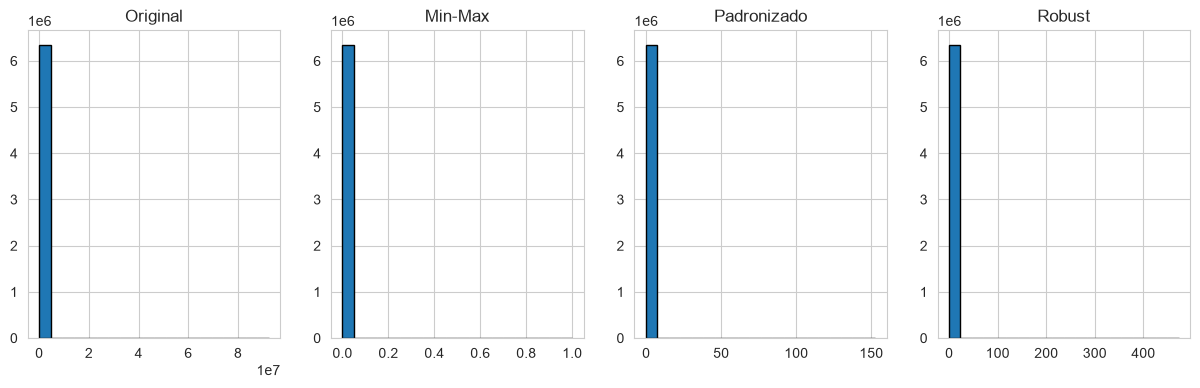

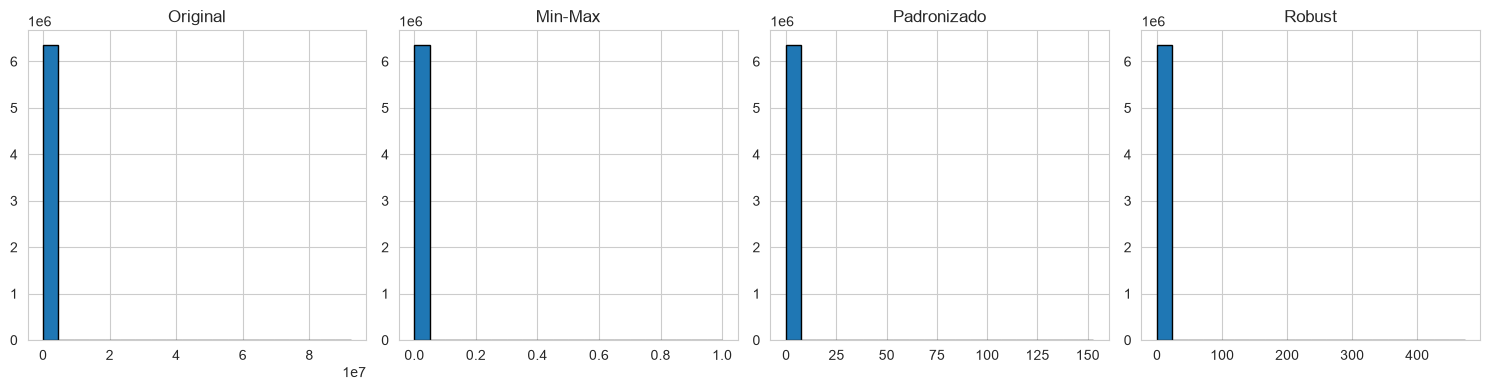

<Figure size 1200x600 with 0 Axes>

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.hist(X_fraud["amount"], bins=20, edgecolor='k')
plt.title("Original")

plt.subplot(1,4,2)
plt.hist(X_fraud_mm[:, X_fraud.columns.get_loc("amount")], bins=20, edgecolor='k')
plt.title("Min-Max")

plt.subplot(1,4,3)
plt.hist(X_fraud_std[:, X_fraud.columns.get_loc("amount")], bins=20, edgecolor='k')
plt.title("Padronizado")

plt.subplot(1,4,4)
plt.hist(X_fraud_rob[:, X_fraud.columns.get_loc("amount")], bins=20, edgecolor='k')
plt.title("Robust")
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# Normalização
scaler_mm = MinMaxScaler()
X_fraud_mm = scaler_mm.fit_transform(X_fraud)

# Padronização
scaler_std = StandardScaler()
X_fraud_std = scaler_std.fit_transform(X_fraud)

# Robust
scaler_robust = RobustScaler()
X_fraud_rob = scaler_robust.fit_transform(X_fraud)

# Visualização da feature "amount"
indice = X_fraud.columns.get_loc("amount")

plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
plt.hist(X_fraud.iloc[:, indice], bins=20, edgecolor='k')
plt.title('Original')

plt.subplot(1,4,2)
plt.hist(X_fraud_mm[:, indice], bins=20, edgecolor='k')
plt.title('Min-Max')

plt.subplot(1,4,3)
plt.hist(X_fraud_std[:, indice], bins=20, edgecolor='k')
plt.title('Padronizado')

plt.subplot(1,4,4)
plt.hist(X_fraud_rob[:, indice], bins=20, edgecolor='k')
plt.title('Robust')

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

Dividir em treino e teste (stratify se classificação).

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [24]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (5090096, 12)
Teste: (1272524, 12)


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'balanceDiffOrig'
]

categorical_features = ['type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [33]:
X_fraud = df.drop("isFraud", axis=1)
y_fraud = df["isFraud"]

# Remover apenas identificadores
X_fraud = X_fraud.drop(columns=["nameOrig", "nameDest"])

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_fraud,
    y_fraud,
    test_size=0.2,
    random_state=42,
    stratify=y_fraud
)

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'step',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balanceDiffOrig',
    'isFlaggedFraud'
]

categorical_features = ['type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

In [37]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

In [39]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 16.9 MB/s eta 0:00:05
    --------------------------------------- 1.3/69.5 MB 3.4 MB/s eta 0:00:21
   - -------------------------------------- 1.8/69.5 MB 3.4 MB/s eta 0:00:21
   - -------------------------------------- 2.4/69.5 MB 3.1 MB/s eta 0:00:22
   - -------------------------------------- 2.9/69.5 MB 3.0 MB/s eta 0:00:23
   - -------------------------------------- 3.4/69.5 MB 2.9 MB/s eta 0:00:23
   -- ------------------------------------- 3.9/69.5 MB 2.8 MB/s eta 0:00:24
   -- ------------------------------------- 4.5/69.5 MB 2.8 MB/s eta 0:00:24
   -- ------------------------------------- 5.0/69.5 MB 2.7 MB/s eta 0:00:24
   --- ------------------------------------ 5.5/69.5 MB 2.7 MB/s eta 0:00:24
   --- ------------------------------------ 6.0/69.5 MB 2.6 MB/s eta 0:00:25
   -

In [40]:
from xgboost import XGBClassifier

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(random_state=42))
])

In [42]:
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['step','type','amount',...,'newbalanceDest','isFlaggedFraud', 'balanceDiffOrig']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'

In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = pipe_rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.9997092392756443
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.80      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

[[1270846      35]
 [    335    1308]]


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, digits=5))

              precision    recall  f1-score   support

           0    0.99974   0.99997   0.99985   1270881
           1    0.97394   0.79610   0.87609      1643

    accuracy                        0.99971   1272524
   macro avg    0.98684   0.89804   0.93797   1272524
weighted avg    0.99970   0.99971   0.99969   1272524



Otimizar hiperparâmetros com GridSearchCV ou RandomizedSearchCV para um dos modelos.

In [46]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# Validação cruzada estratificada
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Espaço de busca dos hiperparâmetros
param_dist = {
    'model__n_estimators': randint(50, 200),
    'model__max_depth': randint(3, 15),
    'model__min_samples_split': randint(2, 10),
    'model__max_features': ['sqrt', 'log2', None]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=1
)

# Treinamento
random_search.fit(X_train, y_train)

# Resultados
print("Melhores parâmetros:")
print(random_search.best_params_)

print("\nMelhor F1-score (validação cruzada):")
print(random_search.best_score_)

Melhores parâmetros:
{'model__max_depth': 14, 'model__max_features': None, 'model__min_samples_split': 5, 'model__n_estimators': 57}

Melhor F1-score (validação cruzada):
0.8693786749939008


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt

# Predições
y_pred = pipe_rf.predict(X_test)
y_proba = pipe_rf.predict_proba(X_test)[:, 1]

# Métricas
print("Acurácia:", accuracy_score(y_test, y_pred))
print("Precisão:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.9997092392756443
Precisão: 0.9739389426656738
Recall: 0.7961046865489957
F1-score: 0.8760884125920965

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.80      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524



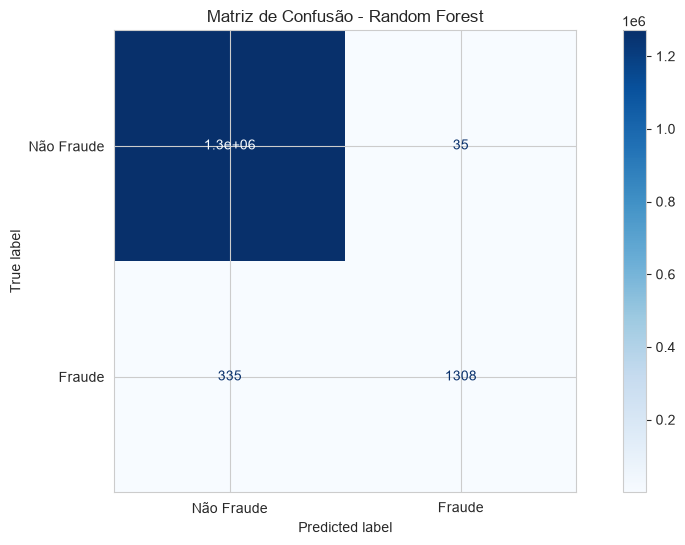

In [48]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não Fraude", "Fraude"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

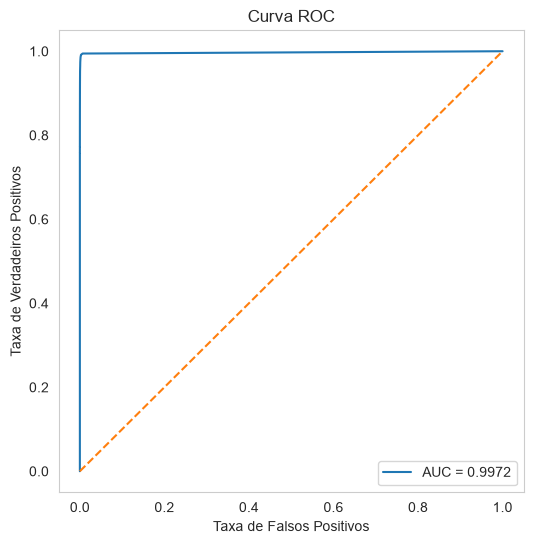

ROC AUC: 0.9971607010112182


In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("Taxa de Falsos Positivos")
plt.ylabel("Taxa de Verdadeiros Positivos")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()

print("ROC AUC:", auc)

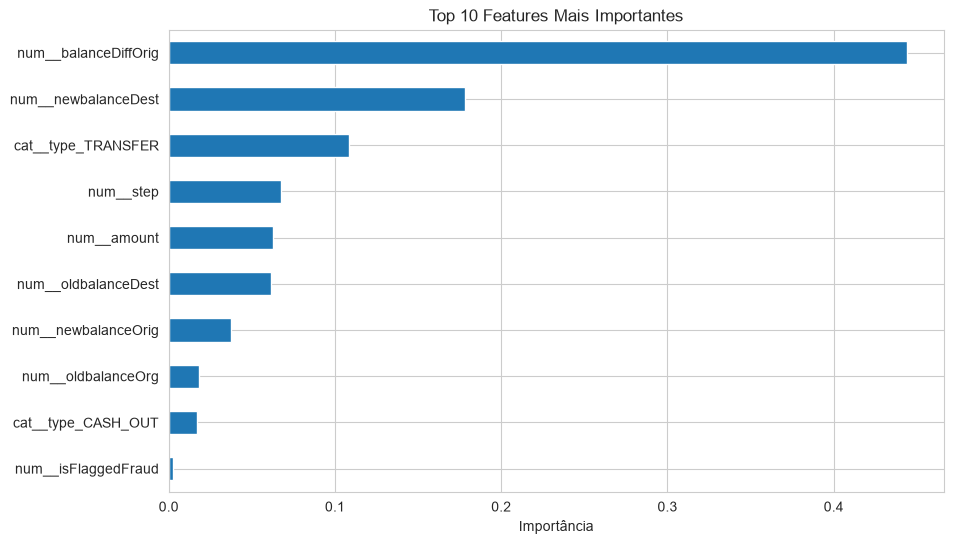

In [52]:
modelo = random_search.best_estimator_

importancias = modelo.named_steps["model"].feature_importances_

feature_names = modelo.named_steps["preprocessor"].get_feature_names_out()

feat_importance = pd.Series(importancias, index=feature_names)
feat_importance = feat_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Features Mais Importantes")
plt.xlabel("Importância")
plt.show()

Agora a parte do discutir sobre overfitting e melhorias, o dataset teve uma taxa muito boa de acuracia e nao teve previsao do modelo, ou seja, resultado real, agora na questao de como melhorar, como os resultados foram muito bons nao teria uma melhora muito consideravel, mas se ainda quiser, precisamos fazer uma otimização mais eficiente para melhorar